# Housing Price Prediction - Decision Tree, Random Forest & XGBoost

# 1. Import Libraries

In [166]:
# Import libraries 
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np

# Print version of each library
print(pd.__version__)
#print(plt.__version__)
print(sns.__version__)
print(np.__version__)

3.0.0
0.13.2
2.3.2


# 2. Data Loading

In [167]:
# Load the Dataset
df = pd.read_csv("../Datasets/Housing.csv")

In [168]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


# 3. Data Splitting

In [169]:
# Spit dataset
from sklearn.model_selection import train_test_split

In [170]:
X = df.drop('price', axis = 1) # Features
y = df['price'] # Target/output

NOTE: Unlike the Ridge/Lasso notebook, we do NOT apply log1p() to y here.  
Tree-based models split data into groups, they don't assume any particular  
distribution of the target. Log-transforming is mainly needed for linear models  
that are sensitive to skewed targets.  

In [171]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 1)
print("X_train Shape:",  X_train.shape)
print("X_test Shape:", X_test.shape)
print("Y_train Shape:", y_train.shape)
print("Y_test Shape:", y_test.shape)

X_train Shape: (381, 12)
X_test Shape: (164, 12)
Y_train Shape: (381,)
Y_test Shape: (164,)


This is a SMALL dataset by ML standards. Tree-based models handle small datasets  
better than linear models in many cases, but are still prone to overfitting.

# 4. Preprocessing

In [172]:
# Identify numerical and categoricla features
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns
print("Numeric Features:", numeric_features)

categorical_features = X_train.select_dtypes(include=['object']).columns
print("Categorical Features:", categorical_features)

Numeric Features: Index(['area', 'bedrooms', 'bathrooms', 'stories', 'parking'], dtype='str')
Categorical Features: Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='str')


C:\Users\56932\AppData\Local\Temp\ipykernel_37476\2813569583.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(include=['object']).columns


Strictly speaking, tree-based models do NOT require feature scaling  
(they split on thresholds, not distances). However, RobustScaler is included  
here for good practice and consistency, it won't hurt and keeps the pipeline  
reusable across model types.  

In [173]:
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# A Pipeline chains steps so they execute in order, and ColumnTransformer applies
# different transformations to different columns simultaneously.

# Why use Pipeline + ColumnTransformer?
#   1. Cleaner code — no manual concatenation needed
#   2. Safer — automatically applies the same transformations to train and test
#   3. No data leakage — fit() only sees training data
#   4. Easy to wrap with GridSearchCV for hyperparameter tuning

numeric_preprocess = Pipeline(steps=[
    ('scaler', RobustScaler())
])

categorical_preprocess = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

preprocess = ColumnTransformer(
    transformers=[
        ('nums', numeric_preprocess, numeric_features ),
        ('cat', categorical_preprocess, categorical_features)
    ]
)


## We will use this to visualize the tree later:
from sklearn.preprocessing import FunctionTransformer

viz_preprocessor = ColumnTransformer([
    ('num', 'passthrough', numeric_features),  # no scaling
    ('cat', OneHotEncoder(drop='first'), categorical_features)
])

# 💡 ALTERNATIVE: You could add feature selection inside the pipeline:
#   from sklearn.feature_selection import SelectKBest, f_regression
#   Pipeline(steps=[('scaler', RobustScaler()), ('selector', SelectKBest(k=10))])
#   This would automatically keep only the top-k most informative numeric features.

# 5. Model - Decision Tree

**Strength:** Highly interpretable, you can visualize every decision the model makes.   
**Weakness:** Prone to overfitting. Without `max_depth`, a tree can memorise the  
training data perfectly (every leaf = one sample) but fail completely on new data.  

In [174]:
# Decision Tree initialization
# sklearn has two tree classes:
#   DecisionTreeClassifier → predicts categories (e.g., spam / not spam)
#   DecisionTreeRegressor  → predicts continuous numbers (e.g., house price)
from sklearn.tree import DecisionTreeRegressor

NOTE: You might see BaseDecisionTree as a internal parent classs of the sklearn library, but you will need to use DecisionTree Regresssor for the user friednly implementation

In [175]:
from sklearn.pipeline import Pipeline

Dtree_pipeline = Pipeline([
    ('preprocessor', preprocess),
    ('regression model', DecisionTreeRegressor(max_depth=4, random_state=1))    
])
#   ALTERNATIVE max_depth values to explore:
#   max_depth=None → fully grown tree (will overfit on small datasets)
#   max_depth=2    → very simple tree (may underfit)
#   max_depth=4    → typical starting point
#   max_depth=6-8  → deeper, more expressive, higher overfitting risk

In [176]:
# .fit() triggers the full pipeline
Dtree_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regression model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('nums', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tra

In [177]:
# After fitting, we can access each step individually using .named_steps[].
# We need these objects separately for visualization (e.g., plotting the tree,
# getting feature names, or inspecting feature importances).
tree_model = Dtree_pipeline.named_steps['regression model']
preprocessor = Dtree_pipeline.named_steps['preprocessor']

In [178]:
# .predict(X_test) applies the train model to unseedn test features
# Pipeline transfomrs X_test into the same scaler encoder as the fitter X_train
# The model outputs a predicted price for each row in X_test
y_Dtree_pred = Dtree_pipeline.predict(X_test)

In [179]:
print("First 10:")
print('Predicted prices: \n', [int(i) for i in y_Dtree_pred[:10]])
print('Real prices: \n', [int(i) for i in y_test[:10]])

First 10:
Predicted prices: 
 [6772957, 5261520, 7896000, 5676222, 3936210, 3625273, 3230145, 5261520, 3625273, 4457119]
Real prices: 
 [7070000, 4550000, 5600000, 6125000, 2940000, 3780000, 2450000, 7490000, 2940000, 6440000]


Many REPEATED predicted values (e.g., 5261520 appears  
twice, 3625273 appears twice). This is a hallmark of Decision Trees, each leaf  
node outputs the AVERAGE price of all training samples that fell into that leaf.  
With max_depth=4, there are at most 2^4=16 possible leaf values, so predictions  
are limited to 16 distinct numbers. The model is "coarse" by design.  

In [180]:
# Example prediction
new_house = pd.DataFrame([{'area': 5000, 'bedrooms': 3, 'bathrooms': 2,
'stories': 2, 'mainroad': 'yes', 'guestroom': 'no', 'basement': 'no',
'hotwaterheating': 'no', 'airconditioning': 'yes', 'parking': 1,
'prefarea': 'no', 'furnishingstatus': 'semi-furnished'}])

predicted_price = Dtree_pipeline.predict(new_house)
print(predicted_price)

[5486468.75]


## 5.1 Evaluation

In [181]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# We define a function to reuse the model evaluation
def evaluate_model(y_true, y_pred, model_name="Model"):
    r2  = r2_score(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)

    print(f"--- {model_name} ---")
    print(f"R-squared:              {r2:.4f}")
    print(f"Mean Squared Error:     {mse:.4f}")
    print(f"Root Mean Sq Error:     {np.sqrt(mse):.4f}")
    print(f"Mean Absolute Error:    {mae:.4f}")
    print()

In [182]:
evaluate_model(y_test, y_Dtree_pred, "Decision Tree")

--- Decision Tree ---
R-squared:              0.4817
Mean Squared Error:     2109716663891.3376
Root Mean Sq Error:     1452486.3730
Mean Absolute Error:    1045662.6379



The model explains only ~48% of price variation. This is relatively  
weak. A coin flip would get R²=0. The remaining 52% is variance the tree cannot  
capture with only 4 levels of splits.  

The core problem: max_depth=4 allows only 16 distinct predictions. The model is  
too simple to capture the price variation in this dataset.

In [183]:
y_pred_Dtree_train = Dtree_pipeline.predict(X_train)
evaluate_model(y_train, y_pred_Dtree_train, "Decision Tree (Train)")

--- Decision Tree (Train) ---
R-squared:              0.6306
Mean Squared Error:     1197892702162.7192
Root Mean Sq Error:     1094482.8469
Mean Absolute Error:    803524.5741



Train R²=0.6306  vs  Test R²=0.4817 → gap of 0.1489  
This is a SIGNIFICANT overfitting signal. The model learned the training data  
noticeably better than it generalises to unseen data.  
With max_depth=4 this gap is already 15 percentage points, deeper trees would  
make this much worse.  

WHY does overfitting happen in Decision Trees?  
Trees can perfectly memorise training data by creating a unique leaf for every  
training sample (no depth limit). max_depth=4 partially controls this, but the  
gap shows it's still not enough regularization for this dataset size.  

## 5.2 Visualizations

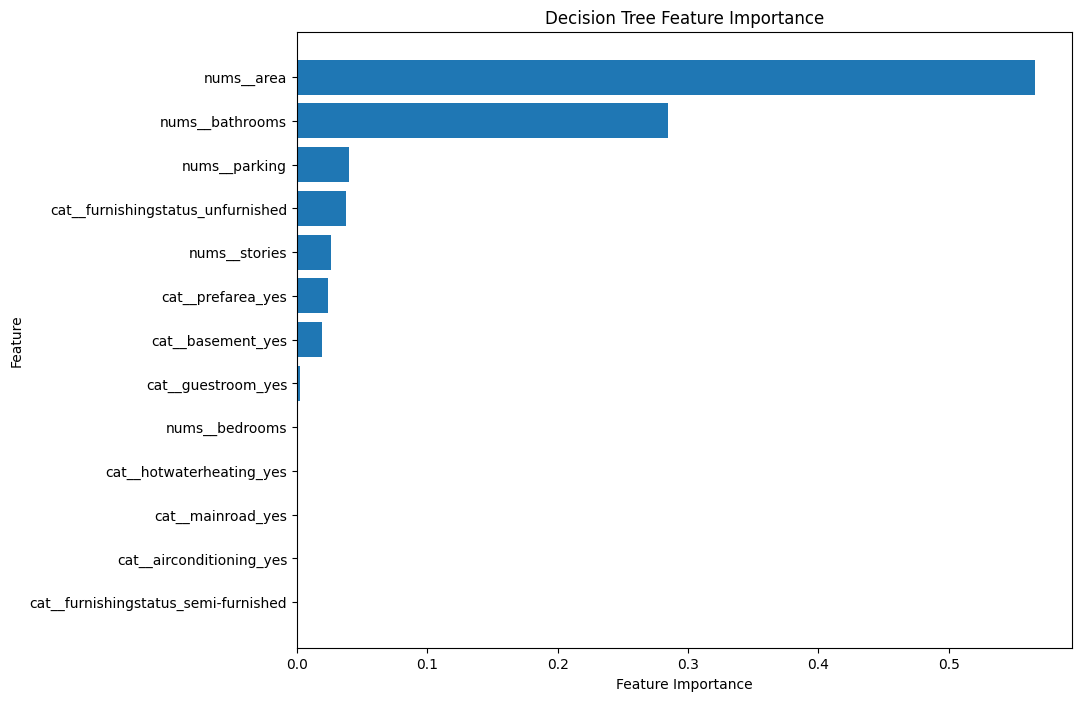

,Feature,Importance
0,nums__area,0.566050
2,nums__bathrooms,0.284564
4,nums__parking,0.040000
12,cat__furnishingstatus_unfurnished,0.037791
3,nums__stories,0.025794
10,cat__prefarea_yes,0.023731
7,cat__basement_yes,0.019425
6,cat__guestroom_yes,0.002646
1,nums__bedrooms,0.000000
8,cat__hotwaterheating_yes,0.000000


In [184]:
# Visualize feature importance
# Get transformed feature names after scaling + one hot encoding
feature_names = preprocessor.get_feature_names_out() # only for labels 

# Build feature importance table
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': tree_model.feature_importances_ # actual number for features.
}).sort_values(by='Importance', ascending=False)

# IMPORTANT: This is different from linear model coefficients. It tells us USAGE
# frequency and impact on splits, not the direction of the relationship.

# Plot
plt.figure(figsize=(10, 8))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Decision Tree Feature Importance')
plt.gca().invert_yaxis()
plt.show()

# Optional: display the table
feature_importance_df.head(15)

This is one of the biggest advantages of Decision Trees over other ML models:  
complete interpretability, you can trace EXACTLY why a price was predicted.

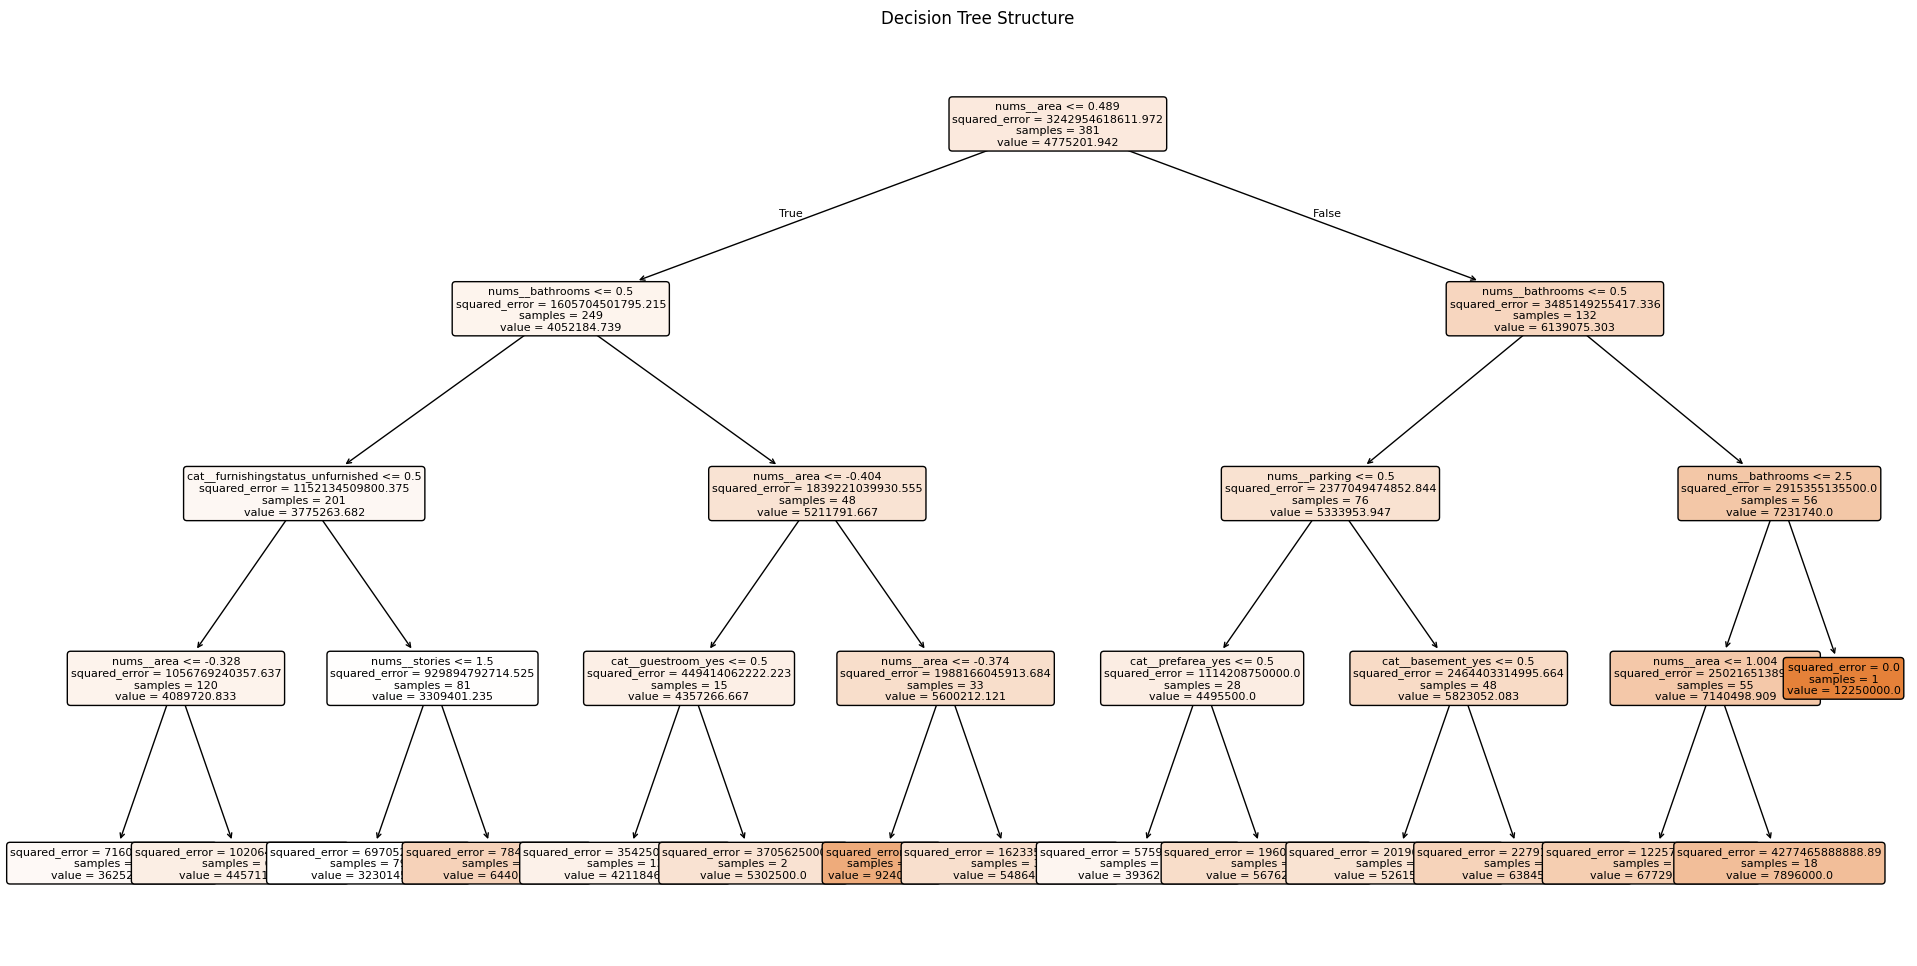

In [185]:
from sklearn.tree import plot_tree

tree_model = Dtree_pipeline.named_steps['regression model']
feature_names = Dtree_pipeline.named_steps['preprocessor'].get_feature_names_out()

plt.figure(figsize=(24, 12))
plot_tree(
    tree_model,
    feature_names=feature_names,
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Decision Tree Structure")
plt.show()

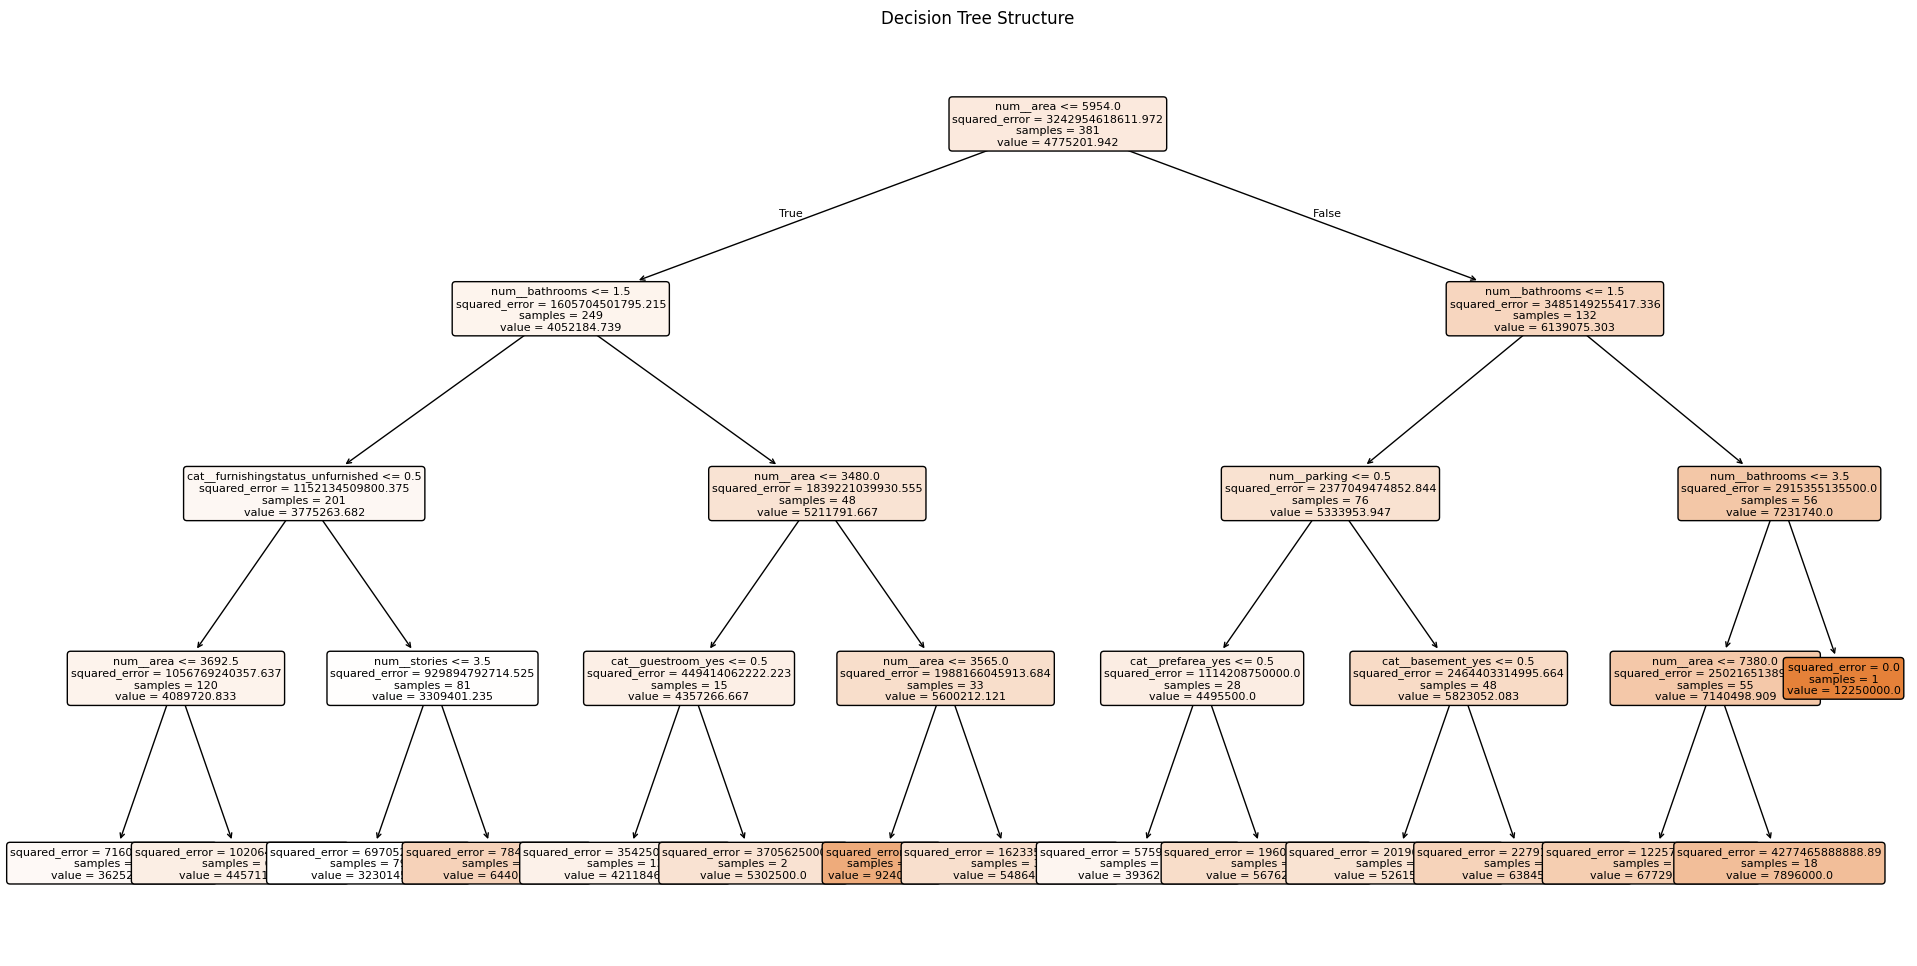

In [186]:
viz_pipeline = Pipeline([
    ('preprocessor', viz_preprocessor),
    ('regression model', DecisionTreeRegressor(max_depth=4))
])

viz_pipeline.fit(X_train, y_train)

viz_tree_model = viz_pipeline.named_steps['regression model']
feature_names = viz_pipeline.named_steps['preprocessor'].get_feature_names_out()

plt.figure(figsize=(24, 12))
plot_tree(
    viz_tree_model,
    feature_names=feature_names,
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Decision Tree Structure")
plt.show()

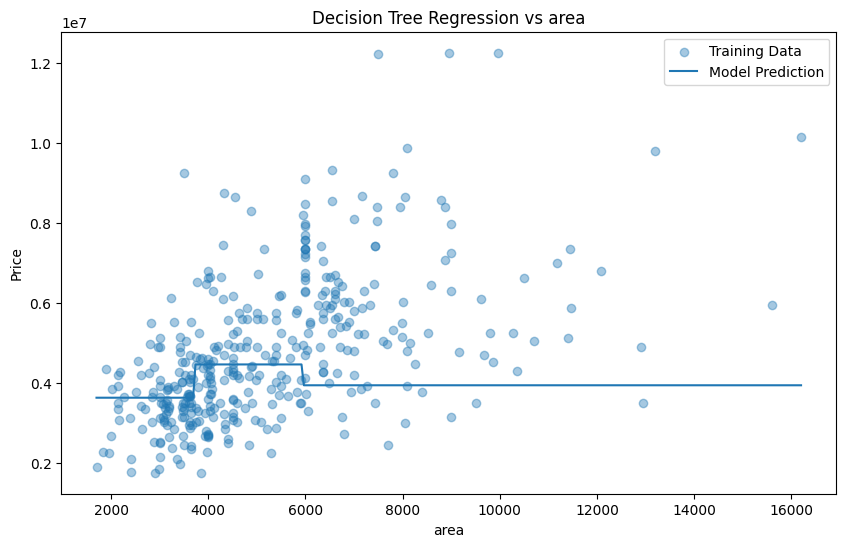

In [187]:
# Partial Dependence Plot

feature_to_vary = 'area'
# This plot answers: "If we hold all other features constant at their typical values,
# how does changing 'area' alone change the predicted price?"

# Create a baseline row using median for numeric and mode for categorical
baseline = X_train.copy()

base_row = {}
for col in X_train.columns:
    if col in numeric_features:
        base_row[col] = X_train[col].median()
    else:
        base_row[col] = X_train[col].mode()[0]

# Create grid over the chosen feature
x_vals = np.linspace(X_train[feature_to_vary].min(), X_train[feature_to_vary].max(), 300)

X_grid = pd.DataFrame([base_row] * len(x_vals))
X_grid[feature_to_vary] = x_vals

# Predict
y_grid_pred = Dtree_pipeline.predict(X_grid)


plt.figure(figsize=(10, 6))
plt.scatter(X_train[feature_to_vary], y_train, alpha=0.4, label='Training Data')
plt.plot(x_vals, y_grid_pred, label='Model Prediction')
plt.title(f"Decision Tree Regression vs {feature_to_vary}")
plt.xlabel(feature_to_vary)
plt.ylabel("Price")
plt.legend()
plt.show()

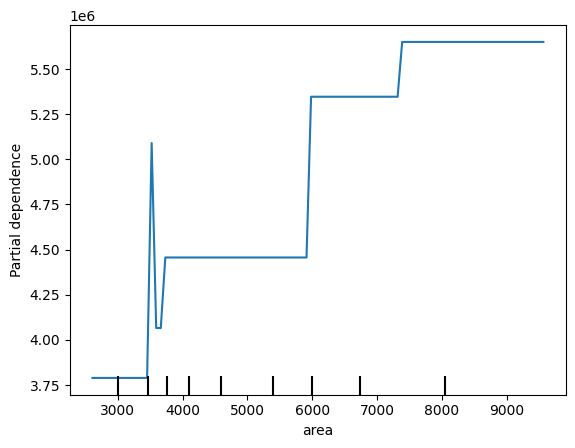

In [188]:
from sklearn.inspection import PartialDependenceDisplay
X_pdp = X_train.copy()
X_pdp[X_pdp.select_dtypes('int64').columns] = X_pdp.select_dtypes('int64').astype(float)
PartialDependenceDisplay.from_estimator(Dtree_pipeline, X_pdp, ['area'])


Why the plots look different:

A decision tree's splits on area can interact with other features. In your manual plot, you're always taking the same path through the tree (because all other features are fixed). With sklearn's PDP, different rows take different paths, and the average smooths or shifts the step pattern.

In short:
Manual = "what does the model predict for a typical house as area changes?"
sklearn PDP = "what is the average marginal effect of area across all houses?"

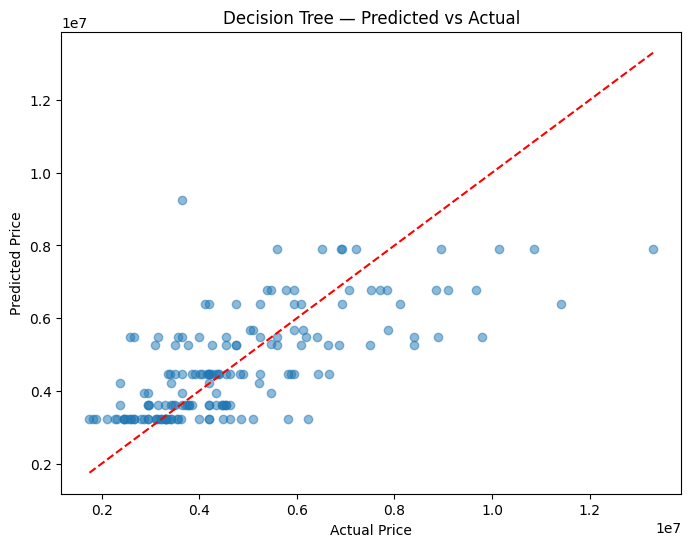

In [189]:
# Predicted vs Actual

# Perfect model → all points on the red diagonal (predicted = actual)
# Points above diagonal → model overestimated
# Points below diagonal → model underestimated

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_Dtree_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Decision Tree — Predicted vs Actual")
plt.show()

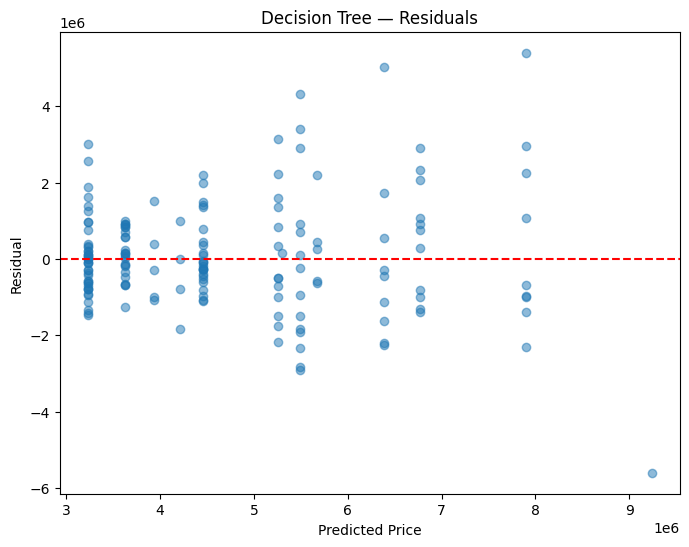

In [190]:
# Residual plot

# Residual = Actual - Predicted
# Good model → residuals scatter randomly around 0 (the red line)
# Pattern in residuals → systematic error the model cannot capture

residuals_dt = y_test - y_Dtree_pred
plt.figure(figsize=(8, 6))
plt.scatter(y_Dtree_pred, residuals_dt, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title("Decision Tree — Residuals")
plt.show()

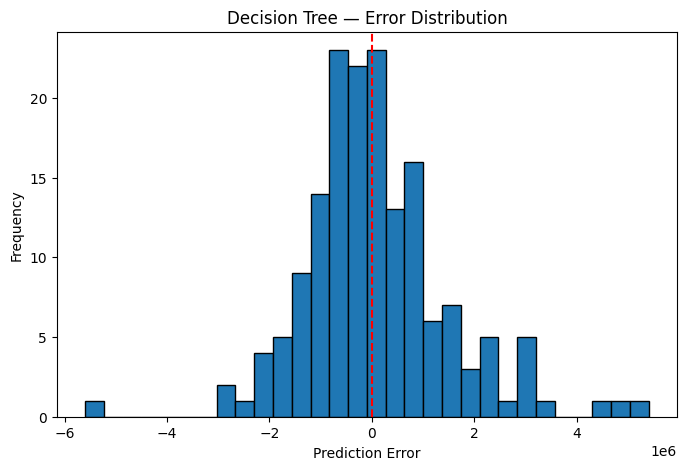

In [191]:
# Error distribution

# Ideal → bell curve centered at 0 (errors are symmetric and random)
# Skewed → model systematically under- or over-estimates in one direction
plt.figure(figsize=(8, 5))
plt.hist(residuals_dt, bins=30, edgecolor='black')
plt.axvline(0, color='red', linestyle='--')
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Decision Tree — Error Distribution")
plt.show()

# 6. Model - Random Forest

 **How does a Random Forest work?**
 A Random Forest trains **many Decision Trees** (100 by default) and averages their
 predictions. Each tree is trained on a **random subset of training samples** (bootstrap
 sampling) and at each split considers only a **random subset of features**.

 This randomness forces each tree to be different — some specialise in area,
 others in location features, others in bathroom count. Averaging them out:
 - Reduces variance → less overfitting than a single tree
 - Creates smoother predictions → partial dependence plots look more realistic
 - Produces more stable feature importances → averaged across 100 trees

 **Trade-off:** Less interpretable than a single tree, but usually much more accurate.

In [192]:
from sklearn.ensemble import RandomForestRegressor

NOTE: RandomForestRegressor lives in sklearn.ensemble because it is an  
"ensemble" method, it combines multiple models (trees) into one stronger model.   
Other ensemble methods in this module: GradientBoostingRegressor, BaggingRegressor.  

In [193]:
# Key hyperparameters:
#   n_estimators=100 → number of trees to train. More trees = more stable but slower.
#                      100 is a common default. Diminishing returns beyond ~200-500.
#   max_depth=4      → limits each individual tree's depth. Same reasoning as before:
#                      prevents each tree from memorising training data.
#                      Without this, each tree would overfit and the average of
#                      100 overfit trees would still overfit.
#   random_state=1   → seeds the randomness for reproducibility

RForest_pipeline = Pipeline([
    ('preprocessor', preprocess),
    ('regression model', RandomForestRegressor(n_estimators=100, random_state=1, max_depth=4))
])
#   ALTERNATIVE hyperparameters to tune (further in this notebook)
#   min_samples_split → minimum samples required to split a node (default=2)
#   min_samples_leaf  → minimum samples required at a leaf (default=1)
#   max_features      → features considered per split ('sqrt', 'log2', or a number)
#   These, combined with max_depth and n_estimators, can be tuned with GridSearchCV.

In [194]:
RForest_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regression model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('nums', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tra

In [195]:
# Get fitted objects from the pipeline
RandomForest_model = RForest_pipeline.named_steps['regression model']
preprocessor = RForest_pipeline.named_steps['preprocessor']

In [196]:
# Generate Predictions
y_pred_RForest = RForest_pipeline.predict(X_test)
print("First 10:")
print('Predicted prices: \n', [int(i) for i in y_pred_RForest[:10]])
print('Real prices: \n', [int(i) for i in y_test[:10]])

First 10:
Predicted prices: 
 [7017346, 5476501, 7960631, 5713020, 4462528, 3736706, 3115974, 5826031, 3390579, 4301738]
Real prices: 
 [7070000, 4550000, 5600000, 6125000, 2940000, 3780000, 2450000, 7490000, 2940000, 6440000]


KEY DIFFERENCE from Decision Tree: predictions are now ALL UNIQUE values.  
There are no repeated numbers because the Random Forest averages 100 trees,  
each tree routes samples slightly differently, producing unique weighted averages.  
This is a much more realistic output than the Decision Tree's staircase values.  

In [197]:
# Example prediction
new_house = pd.DataFrame([{'area': 5000, 'bedrooms': 3, 'bathrooms': 2,
'stories': 2, 'mainroad': 'yes', 'guestroom': 'no', 'basement': 'no',
'hotwaterheating': 'no', 'airconditioning': 'yes', 'parking': 1,
'prefarea': 'no', 'furnishingstatus': 'semi-furnished'}])

predicted_price = RForest_pipeline.predict(new_house)
print(predicted_price)

[5696377.89413473]


## 6.1 Evaluation

In [198]:
evaluate_model(y_test, y_pred_RForest, "Random Forest")

--- Random Forest ---
R-squared:              0.6090
Mean Squared Error:     1591517284492.6213
Root Mean Sq Error:     1261553.5203
Mean Absolute Error:    913846.0420



In [199]:
y_pred_train = RForest_pipeline.predict(X_train)
evaluate_model(y_train, y_pred_train, "Random Forest (Train)")

--- Random Forest (Train) ---
R-squared:              0.7057
Mean Squared Error:     954349353898.0228
Root Mean Sq Error:     976908.0581
Mean Absolute Error:    731567.5578



Both models still show significant Train > Test gaps.

ROOT CAUSE: max_depth=4 is the same for both models. With 100 trees each of  
depth 4, the forest has more capacity than a single tree and captures more  
training patterns — but also overfits more.  
SOLUTION: Try deeper trees (max_depth=6-8) with more n_estimators, OR use  
GridSearchCV to find the optimal depth that minimises the test-train gap.  

## 6.2 Visualization

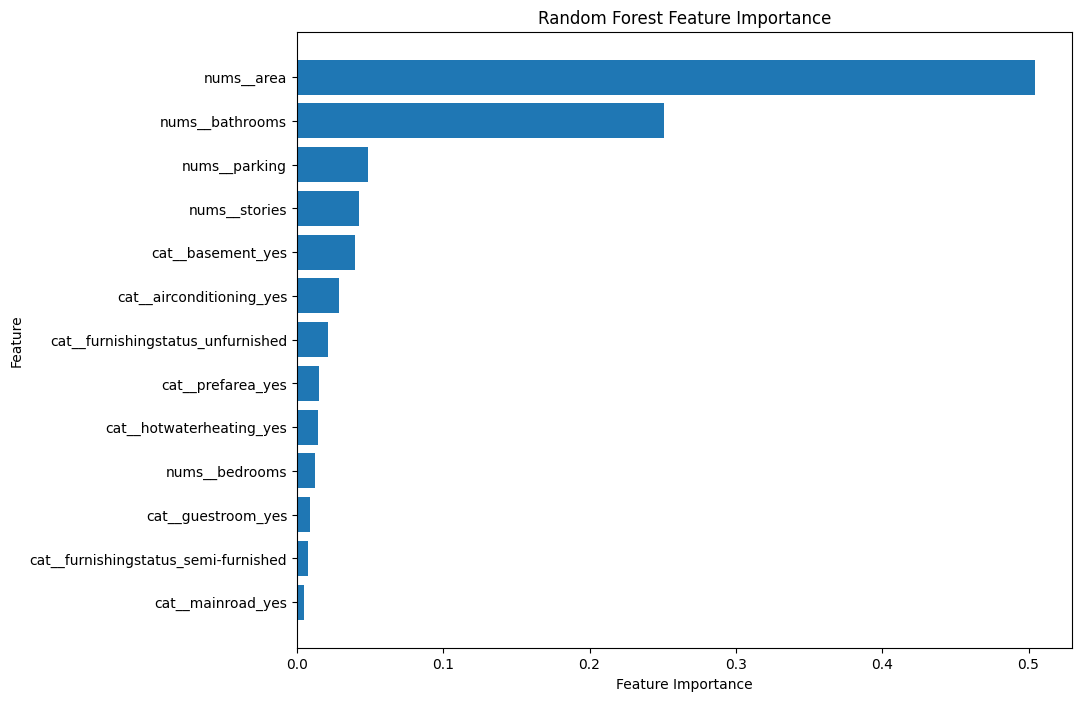

,Feature,Importance
0,nums__area,0.504427
2,nums__bathrooms,0.251024
4,nums__parking,0.048698
3,nums__stories,0.042733
7,cat__basement_yes,0.039471
9,cat__airconditioning_yes,0.028765
12,cat__furnishingstatus_unfurnished,0.021100
10,cat__prefarea_yes,0.015094
8,cat__hotwaterheating_yes,0.014729
1,nums__bedrooms,0.012266


In [200]:
# Visualize feature importante
# Get transformed feature names after scaling + one hot encoding
feature_names = preprocessor.get_feature_names_out()

# Random Forest feature importances are AVERAGED across all 100 trees.
# This makes them much more stable and reliable than single-tree importances.
# A feature that is important in 90/100 trees will score high.
# A feature that happened to be important in one tree by luck will score low.
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': RandomForest_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 8))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Random Forest Feature Importance')
plt.gca().invert_yaxis()
plt.show()

# Optional: display the table
feature_importance_df.head(15)

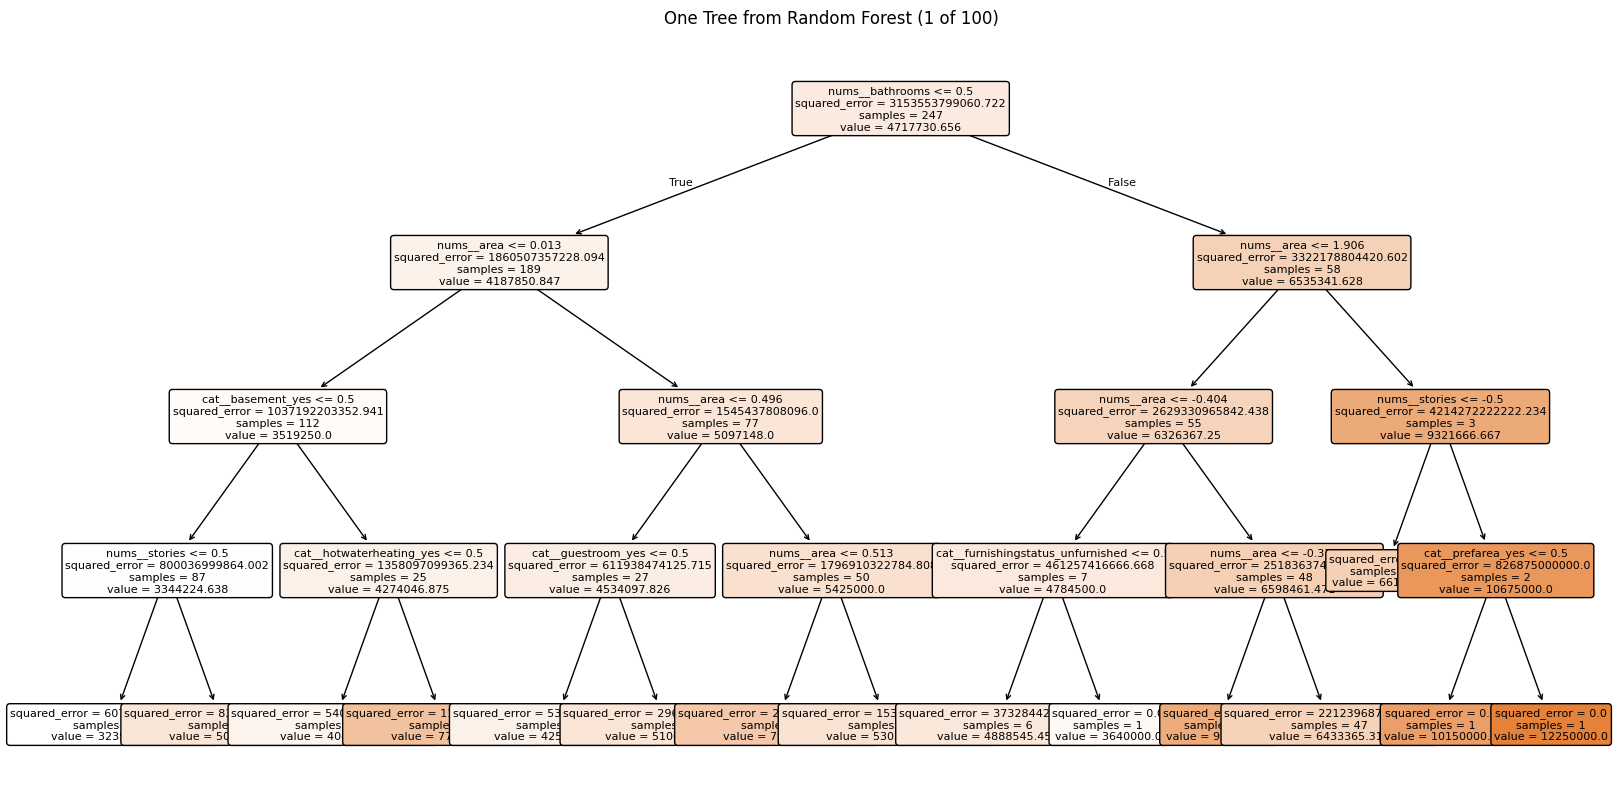

In [201]:
# We cannot visualize all 100 trees (too many). Instead, we plot ONE representative
# tree from the forest. This gives intuition about the structure of individual trees,
# but remember: the actual prediction is the average of ALL 100 trees.
#
# estimators_[0] → the first tree trained (arbitrary choice, any index works)

feature_names = RForest_pipeline.named_steps['preprocessor'].get_feature_names_out()
tree_to_plot = RandomForest_model.estimators_[0]

plt.figure(figsize=(20, 10))
plot_tree(
    tree_to_plot,
    max_depth=4,
    feature_names=feature_names,
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("One Tree from Random Forest (1 of 100)")
plt.show()

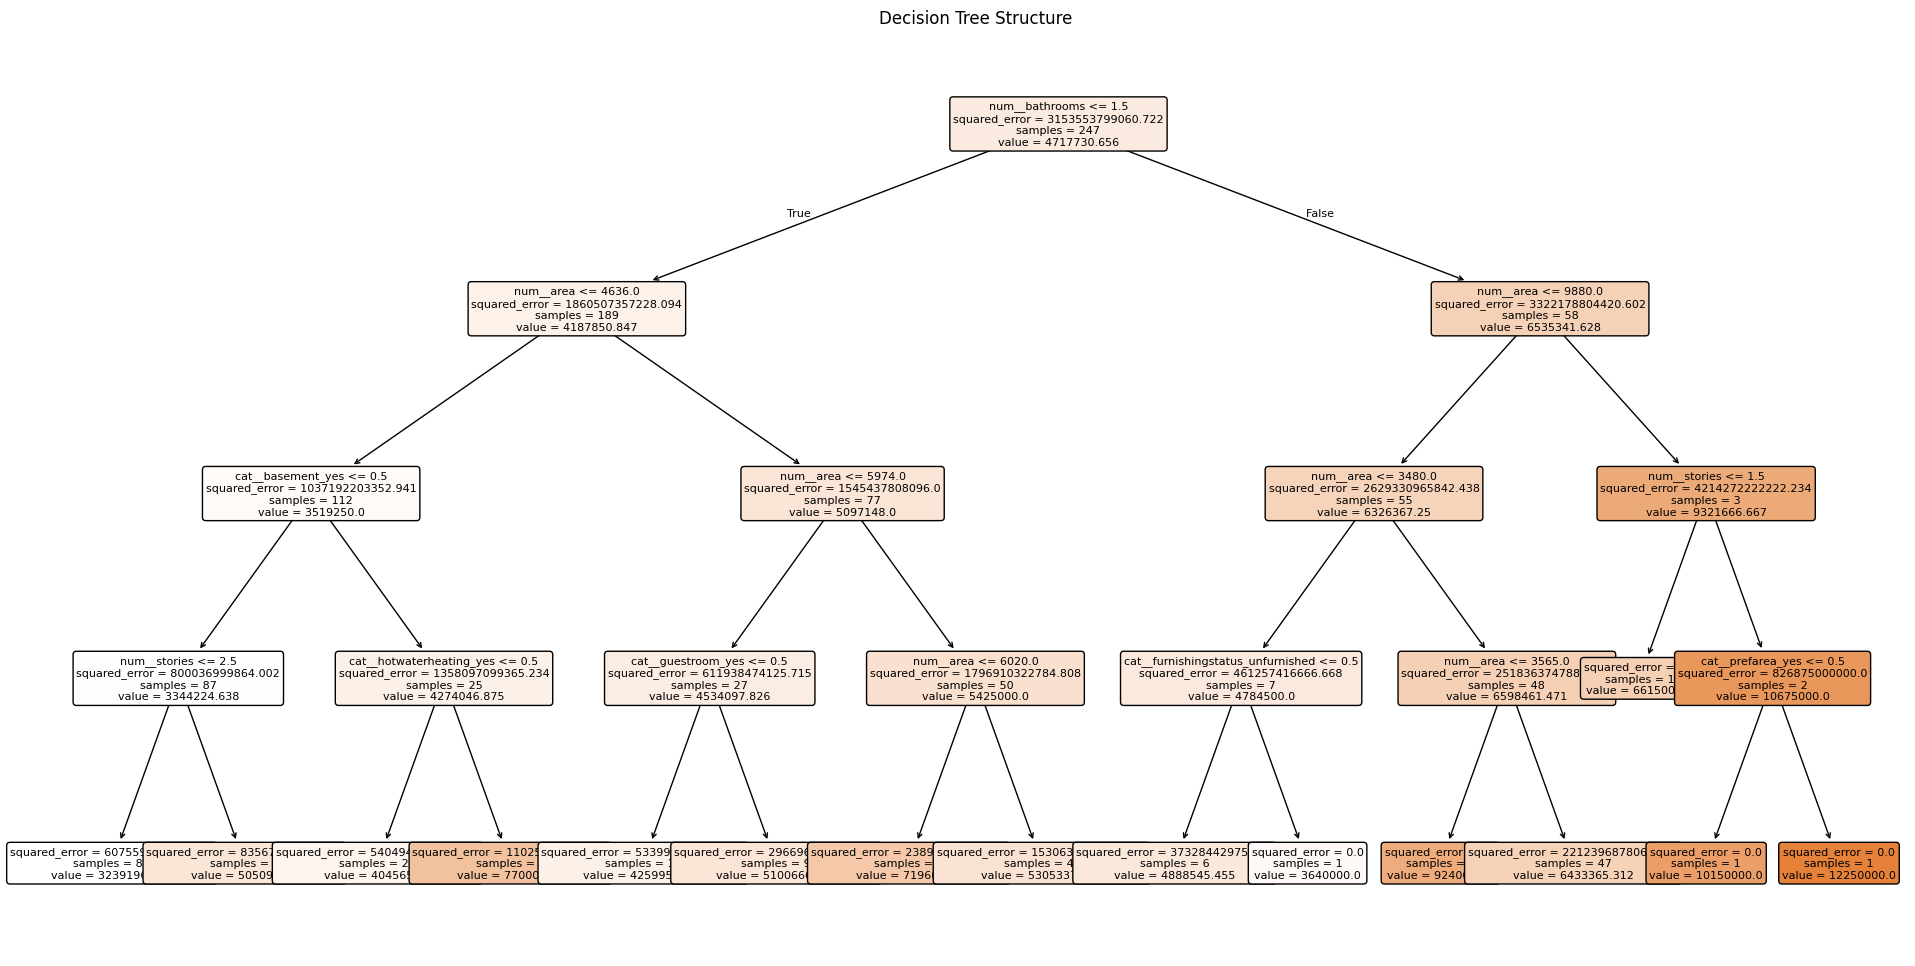

In [202]:
viz_pipeline = Pipeline([
    ('preprocessor', viz_preprocessor),
    ('regression model', RandomForestRegressor(n_estimators=100, random_state=1, max_depth=4))
])

viz_pipeline.fit(X_train, y_train)

viz_tree_model = viz_pipeline.named_steps['regression model']
feature_names = viz_pipeline.named_steps['preprocessor'].get_feature_names_out()

tree_to_plot = viz_tree_model.estimators_[0]

plt.figure(figsize=(24, 12))
plot_tree(
    tree_to_plot,
    feature_names=feature_names,
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Decision Tree Structure")
plt.show()

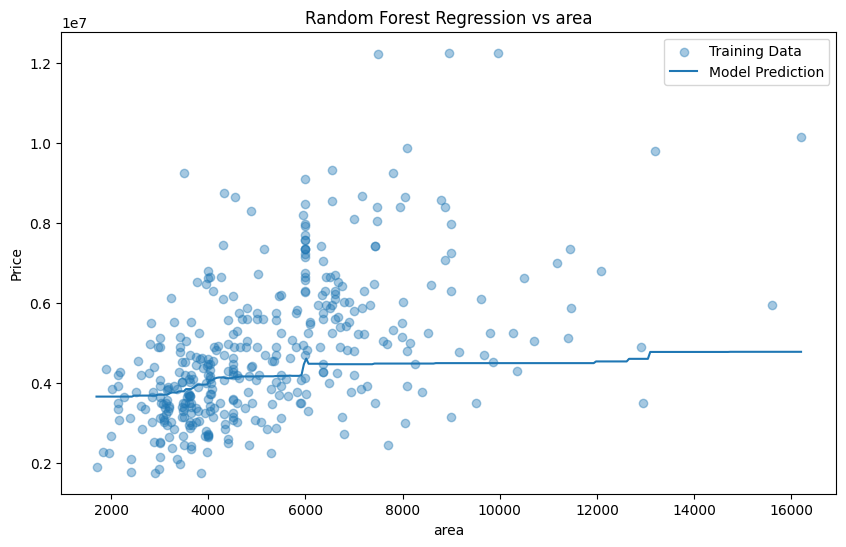

In [203]:
feature_to_vary = 'area'

# Create a baseline row using median for numeric and mode for categorical
baseline = X_train.copy()

base_row = {}
for col in X_train.columns:
    if col in numeric_features:
        base_row[col] = X_train[col].median()
    else:
        base_row[col] = X_train[col].mode()[0]

# Create grid over the chosen feature
x_vals = np.linspace(X_train[feature_to_vary].min(), X_train[feature_to_vary].max(), 300)

X_grid = pd.DataFrame([base_row] * len(x_vals))
X_grid[feature_to_vary] = x_vals

# Predict
y_grid_pred = RForest_pipeline.predict(X_grid)


plt.figure(figsize=(10, 6))
plt.scatter(X_train[feature_to_vary], y_train, alpha=0.4, label='Training Data')
plt.plot(x_vals, y_grid_pred, label='Model Prediction')
plt.title(f"Random Forest Regression vs {feature_to_vary}")
plt.xlabel(feature_to_vary)
plt.ylabel("Price")
plt.legend()
plt.show()

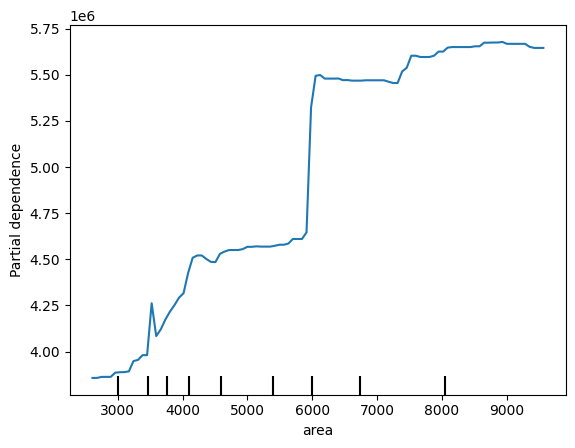

In [204]:
X_pdp = X_train.copy()
X_pdp[X_pdp.select_dtypes('int64').columns] = X_pdp.select_dtypes('int64').astype(float)
PartialDependenceDisplay.from_estimator(RForest_pipeline, X_pdp, ['area'])

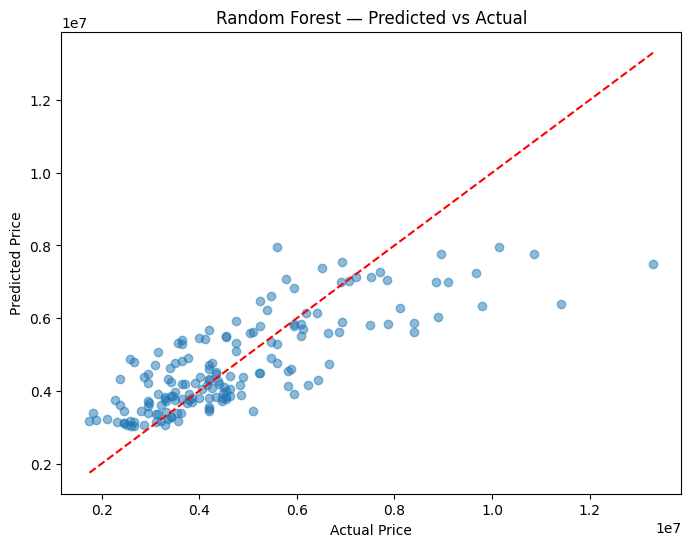

In [205]:
# Predicted vs Actual
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_RForest, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Random Forest — Predicted vs Actual")
plt.show()

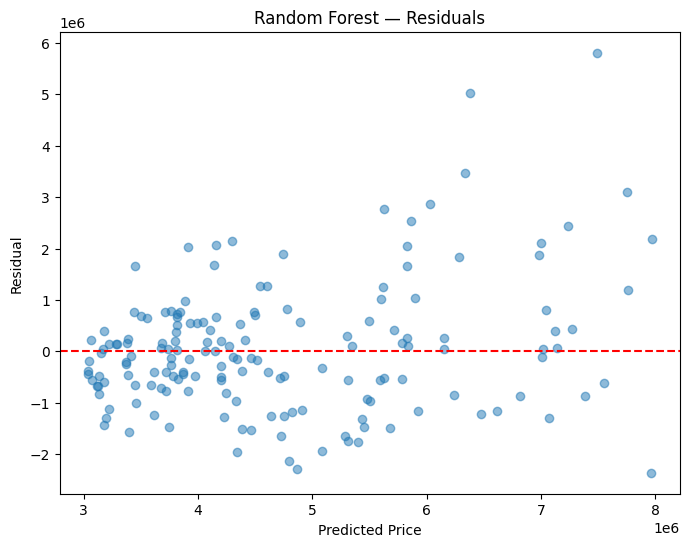

In [206]:
# Residual plot
residuals_rf = y_test - y_pred_RForest
plt.figure(figsize=(8, 6))
plt.scatter(y_pred_RForest, residuals_rf, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title("Random Forest — Residuals")
plt.show()

Residuals: Look for FUNNEL shape, wider spread at high predicted prices.
This is called heteroscedasticity: the model is less precise for expensive houses.
Common in housing data where luxury properties have more idiosyncratic pricing.

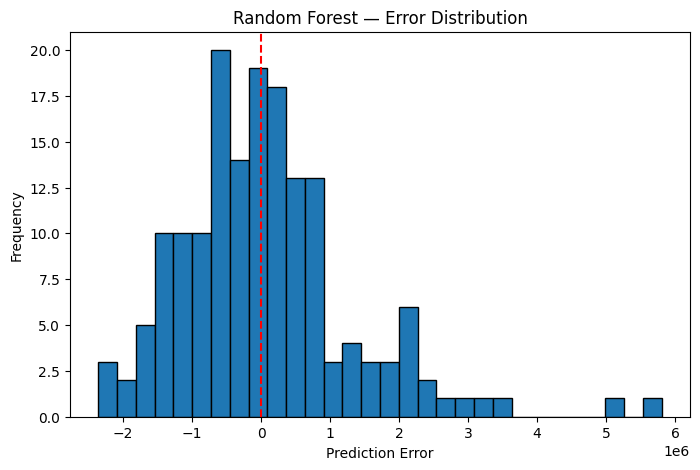

In [207]:
# Error distribution
plt.figure(figsize=(8, 5))
plt.hist(residuals_rf, bins=30, edgecolor='black')
plt.axvline(0, color='red', linestyle='--')
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Random Forest — Error Distribution")
plt.show()

# 7. Model - XGBoost

**How does XGBoost work?**
XGBoost (Extreme Gradient Boosting) also builds many Decision Trees, but uses a
fundamentally different strategy than Random Forest:
- **Random Forest:** Trees are built IN PARALLEL, independently, then averaged
- **XGBoost:** Trees are built SEQUENTIALLY. Each new tree specifically targets
  the **errors** of all previous trees combined
This sequential error-correction process is called **Gradient Boosting**.
Each tree is a "specialist" that corrects what the previous trees got wrong.
**`learning_rate`:** Controls how much each new tree's correction is weighted.
Low learning rate (0.05-0.1) + more trees → smoother, more careful learning.
High learning rate → faster but risks overshooting the optimal solution.  
**XGBoost vs Random Forest:** XGBoost generally achieves higher accuracy but
is more prone to overfitting and requires more careful tuning.


In [208]:
from xgboost import XGBRegressor

# XGBRegressor key parameters:
#   n_estimators=100   → number of sequential trees (boosting rounds)
#   max_depth=4        → maximum depth per tree (shallower = more regularized)
#   learning_rate=0.1  → step size for each correction (shrinkage).
#                        Lower = more conservative, needs more trees.
#   random_state=1     → reproducibility

xgb_pipeline = Pipeline([
    ('preprocessor', preprocess),
    ('regression model', XGBRegressor(n_estimators=100, random_state=1, max_depth=4, learning_rate=0.1))
])

#   ALTERNATIVE: XGBoost has many additional regularization parameters:
#   subsample     → fraction of training samples used per tree (like bagging)
#   colsample_bytree → fraction of features used per tree
#   reg_alpha     → L1 regularization (like Lasso) on leaf weights
#   reg_lambda    → L2 regularization (like Ridge) on leaf weights
# These can be tuned with GridSearchCV or Optuna for better results.

In [209]:
xgb_pipeline.fit(X_train, y_train)

XGB_model = xgb_pipeline.named_steps['regression model']
y_pred_XGB = xgb_pipeline.predict(X_test)

print("First 10:")
print('Predicted prices: \n', [int(i) for i in y_pred_XGB[:10]])
print('Real prices: \n', [int(i) for i in y_test[:10]])

First 10:
Predicted prices: 
 [7009344, 5450062, 7388019, 6037091, 3999390, 3453926, 3450086, 6307580, 2822013, 4316660]
Real prices: 
 [7070000, 4550000, 5600000, 6125000, 2940000, 3780000, 2450000, 7490000, 2940000, 6440000]


In [210]:
# Example prediction
new_house = pd.DataFrame([{'area': 5000, 'bedrooms': 3, 'bathrooms': 2,
'stories': 2, 'mainroad': 'yes', 'guestroom': 'no', 'basement': 'no',
'hotwaterheating': 'no', 'airconditioning': 'yes', 'parking': 1,
'prefarea': 'no', 'furnishingstatus': 'semi-furnished'}])

predicted_price = xgb_pipeline.predict(new_house)
print(predicted_price)

[6.246349e+06]


## 7.1 Evaluation

In [211]:
evaluate_model(y_test, y_pred_XGB, "XGBoost")

y_pred_XGB_train = xgb_pipeline.predict(X_train)
evaluate_model(y_train, y_pred_XGB_train, "XGBoost (Train)")

--- XGBoost ---
R-squared:              0.6866
Mean Squared Error:     1275820113920.0000
Root Mean Sq Error:     1129522.0732
Mean Absolute Error:    832709.0625

--- XGBoost (Train) ---
R-squared:              0.9099
Mean Squared Error:     292153098240.0000
Root Mean Sq Error:     540511.8854
Mean Absolute Error:    408123.1562



XGBoost is extremely powerful, it achieved 91% R² on training data, meaning  
it nearly memorised the training set. But it only generalises to 69% on new data.  
The sequential boosting process keeps adding trees that correct training errors,  
eventually fitting the training data almost perfectly, even noise.  

HOWEVER: Despite this gap, XGBoost has the BEST test performance of the three:  
  Test R²: XGBoost (0.6866) > Random Forest (0.6090) > Decision Tree (0.4817)  
Higher accuracy + higher overfitting risk is the XGBoost trade-off.  

SOLUTION: Reduce n_estimators, add early stopping, lower learning_rate,  
or increase regularization (reg_alpha, reg_lambda) to close the train-test gap.  

## 7.2 Visualizations

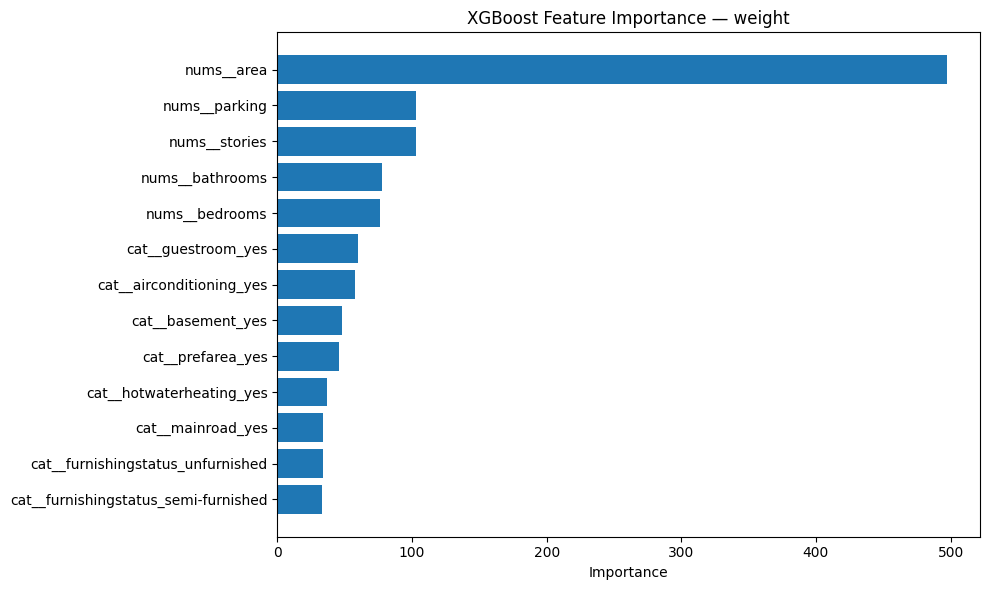

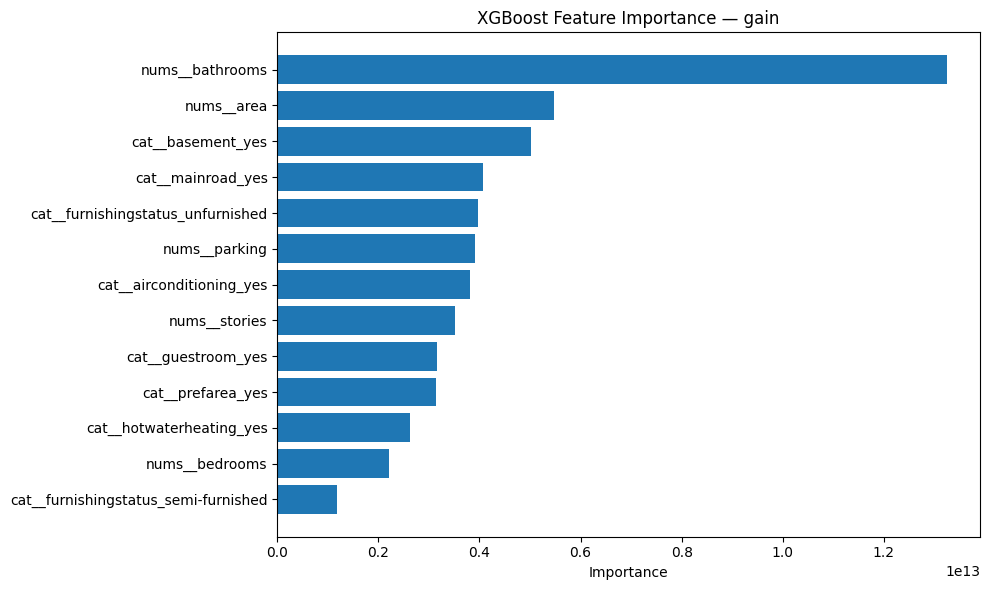

,Feature,Importance
0,nums__area,0.504427
2,nums__bathrooms,0.251024
4,nums__parking,0.048698
3,nums__stories,0.042733
7,cat__basement_yes,0.039471
9,cat__airconditioning_yes,0.028765
12,cat__furnishingstatus_unfurnished,0.021100
10,cat__prefarea_yes,0.015094
8,cat__hotwaterheating_yes,0.014729
1,nums__bedrooms,0.012266


In [212]:
# Feature Importance
# XGBoost's default feature_importances_ uses 'gain' — the average improvement
# in the loss function brought by a feature across all splits where it is used.
booster = XGB_model.get_booster()
feature_names = xgb_pipeline.named_steps['preprocessor'].get_feature_names_out()

for imp_type in ['weight', 'gain']:
    scores = booster.get_score(importance_type=imp_type)
    # map f0, f1... back to real names
    imp_df = pd.DataFrame({
        'Feature': [feature_names[int(k[1:])] for k in scores],
        'Importance': list(scores.values())
    }).sort_values('Importance', ascending=False)

    plt.figure(figsize=(10, 6))
    plt.barh(imp_df['Feature'], imp_df['Importance'])
    plt.gca().invert_yaxis()
    plt.title(f'XGBoost Feature Importance — {imp_type}')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()

feature_importance_df.head(15)

# XGBoost importance rankings often differ from Random Forest because:
# 1. XGBoost uses sequential trees — early trees dominate later ones
# 2. 'gain' measures how much a feature IMPROVES the loss, not just usage count
# 'area' will still lead, but the relative ranking of other features may differ.
# Features that help correct specific errors (boosting target) may rank higher here.

# 'weight' → how many times a feature is used to split across all trees
#             (frequency of use — can be misleading if a feature splits often but poorly)
# 'gain'   → average improvement in prediction quality brought by splits on this feature
#             (quality of use — generally the better metric for importance)
#
# If a feature ranks high in weight but low in gain: it's used often but doesn't
# help much — a candidate for removal.
# If a feature ranks high in gain but low in weight: it's used rarely but very
# impactfully when it is — a highly informative feature.

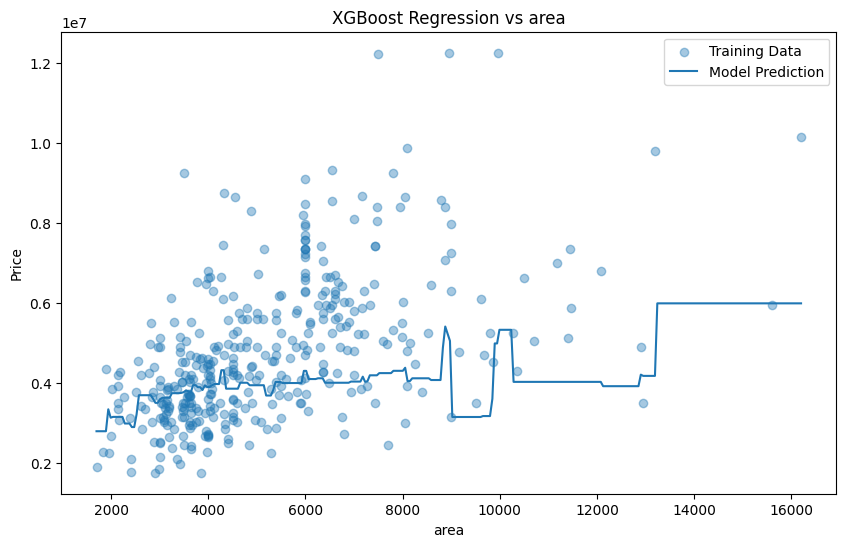

In [213]:
# Scatter vs area
feature_to_vary = 'area'

base_row = {}
for col in X_train.columns:
    if col in numeric_features:
        base_row[col] = X_train[col].median()
    else:
        base_row[col] = X_train[col].mode()[0]

x_vals = np.linspace(X_train[feature_to_vary].min(), X_train[feature_to_vary].max(), 300)
X_grid = pd.DataFrame([base_row] * len(x_vals))
X_grid[feature_to_vary] = x_vals

y_grid_pred = xgb_pipeline.predict(X_grid)

plt.figure(figsize=(10, 6))
plt.scatter(X_train[feature_to_vary], y_train, alpha=0.4, label='Training Data')
plt.plot(x_vals, y_grid_pred, label='Model Prediction')
plt.title(f"XGBoost Regression vs {feature_to_vary}")
plt.xlabel(feature_to_vary)
plt.ylabel("Price")
plt.legend()
plt.show()

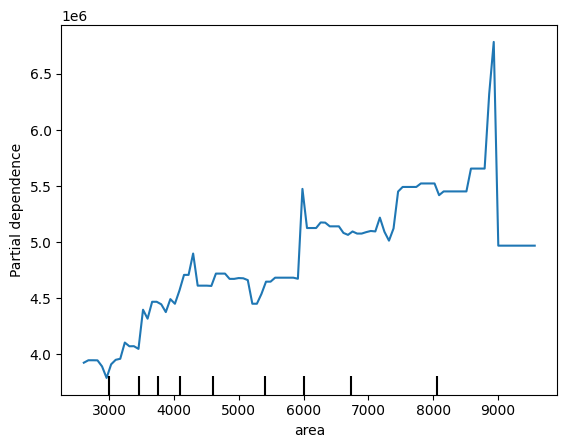

In [214]:
X_pdp = X_train.copy()
X_pdp[X_pdp.select_dtypes('int64').columns] = X_pdp.select_dtypes('int64').astype(float)
PartialDependenceDisplay.from_estimator(xgb_pipeline, X_pdp, ['area'])

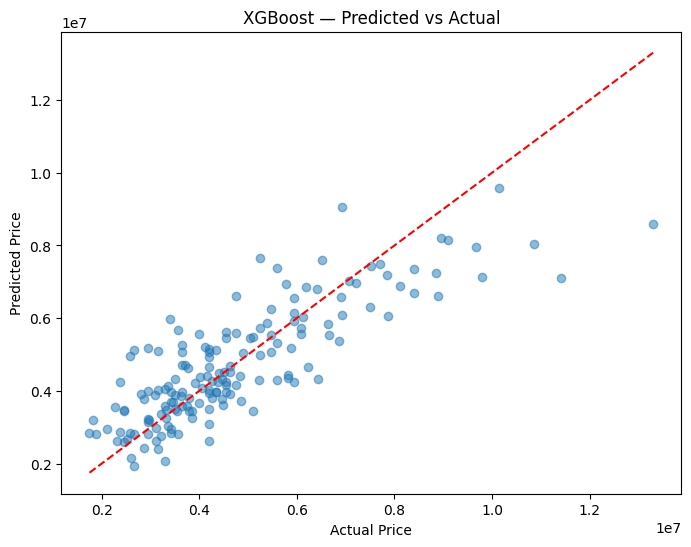

In [ ]:
# Predicted vs Actual
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_XGB, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("XGBoost — Predicted vs Actual")
plt.show()

Show the tightest cluster along the diagonal of the  
three models — consistent with having the best test R² (0.6866).  
However, very high-priced houses (outliers) will still show large errors.  

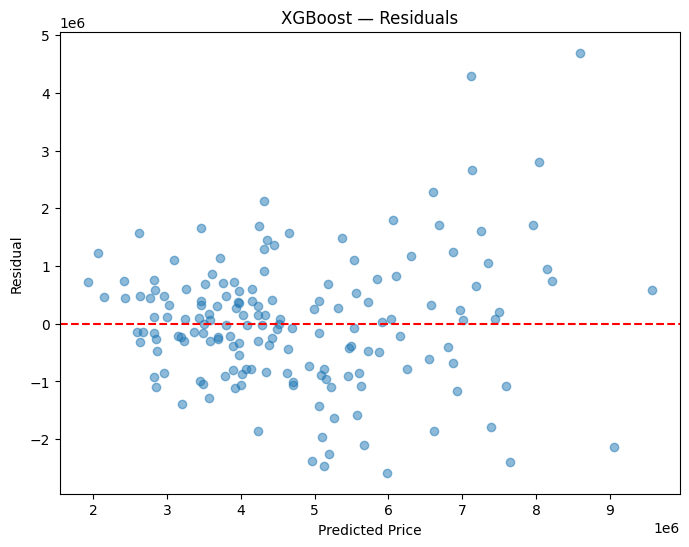

In [ ]:
# Residual plot
residuals_xgb = y_test - y_pred_XGB
plt.figure(figsize=(8, 6))
plt.scatter(y_pred_XGB, residuals_xgb, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title("XGBoost — Residuals")
plt.show()

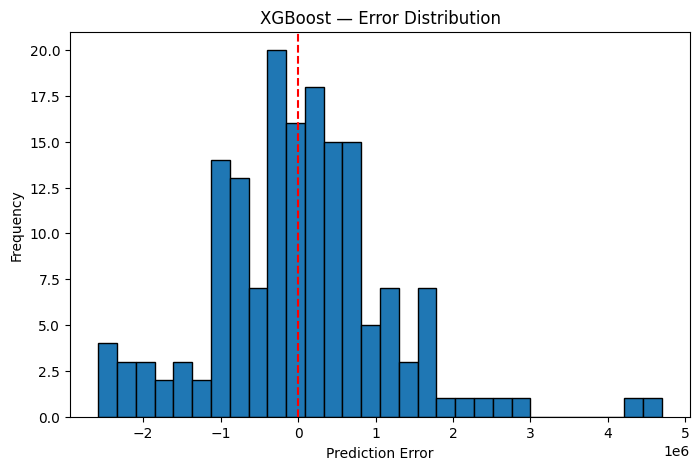

In [161]:
# Error distribution
plt.figure(figsize=(8, 5))
plt.hist(residuals_xgb, bins=30, edgecolor='black')
plt.axvline(0, color='red', linestyle='--')
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("XGBoost — Error Distribution")
plt.show()

# 8. Hyperparameter tuning